In [ ]:
import os
import random
import yaml
import cv2 # -> OpenCV 
import matplotlib.pyplot as plt
from pathlib import Path

## Exploración inicial del dataset.

#### Rutas Principales

In [15]:
RAW_PATH = Path("../data/raw")
TRAIN_IMAGES = RAW_PATH / "train" / "images"
TRAIN_LABELS = RAW_PATH / "train" / "labels"


##### Contar Imágenes y labels

In [16]:
formatos = set(img.suffix for img in TRAIN_IMAGES.iterdir())
print(f"Formatos encontrados: {formatos}")

Formatos encontrados: {'.jpg', '.jpeg', '.webp', '.png'}


Nota: tenemos diferentes formatos de imagenes

In [17]:
imagenes =  list(TRAIN_IMAGES.glob("*.jpg")) + \
            list(TRAIN_IMAGES.glob("*.jpeg")) + \
            list(TRAIN_IMAGES.glob("*.webp")) + \
            list(TRAIN_IMAGES.glob("*.png"))

labels = list(TRAIN_LABELS.glob("*.txt"))
print(f"Total imágenes: {len(imagenes)}")
print(f"Total labels: {len(labels)}")

Total imágenes: 281
Total labels: 281


In [25]:
sin_label = []
sin_imagen = []

for img in imagenes:
    label_esperado = TRAIN_LABELS / (img.stem + ".txt")
    if not label_esperado.exists():
        sin_label.append(img.name)

for label in labels:
    imagen_esperada_jpg = TRAIN_IMAGES / (label.stem + ".jpg")
    imagen_esperada_jpeg = TRAIN_IMAGES / (label.stem + ".jpeg")
    imagen_esperada_webp = TRAIN_IMAGES / (label.stem + ".webp")
    imagen_esperada_png = TRAIN_IMAGES / (label.stem + ".png")

    if not any([imagen_esperada_jpg.exists(),
                imagen_esperada_jpeg.exists(),
                imagen_esperada_webp.exists(),
                imagen_esperada_png.exists()]):
        sin_imagen.append(label.name)

print(f"imagenes sin label: {len(sin_label)}")
print(f"labels sin imagen: {len(sin_imagen)}")

imagenes sin label: 0
labels sin imagen: 0


Nota: Toda imagen tiene su Label (anotación)

#### Distribución de clases (placas de carro vs moto)

In [ ]:
clases = {0:0,1:0} # 0 = placa_carro, 1 = placo_moto

for label in labels:
    with open(label, 'r') as f:
        for linea in f.readlines():
            clase = int(linea.strip().split()[0])
            clases[clase] += 1

print(f"Placa carro (clase 0): {clases[0]}")
print(f"Placa Moto (clase 1): {clases[1]}")
print(f"Total anotaciones: {sum(clases.values())}")



Placa carro (clase 0): 248
Placa carro (clase 1): 43
Total anotaciones: 291


Nota: algunas imágenes cuentan con mas de una placa, así que si por ejemplo una imagen tiene dos placas, su label tendrá dos anotaciones, por otro lado se ve que tenemos mas placas de carros que de motos, por lo que el modelo aprenderá mejor a detectar las placas de los carros que de las motos 

#### Gráfica


<function matplotlib.pyplot.show(close=None, block=None)>

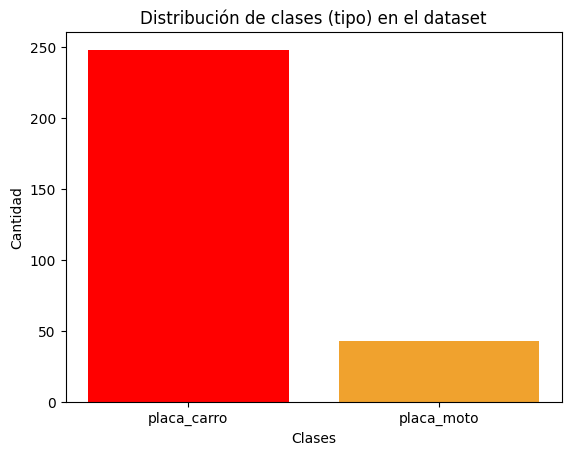

In [23]:
plt.Figure(figsize=(6,4))
plt.bar(['placa_carro', 'placa_moto'], [clases[0], clases[1]],color=["#ff0000", "#F0A22E"])
plt.title('Distribución de clases (tipo) en el dataset')
plt.ylabel('Cantidad')
plt.xlabel('Clases')
plt.show

Nota: Aquí vemos mejor visualmente la diferencia de cantidad entre las clases

# Limpieza y validación de imágenes y anotaciones.

#### Validación anotaciones

In [64]:
# Análisis completo de formatos de labels
formatos_encontrados = set()
detalle_labels = {
    'validos': 0,
    'vacios': 0,
    'desconocidos': 0
}
detalle_lineas = {}

for label_path in labels:
    with open(label_path, 'r') as f:
        lineas = [l.strip() for l in f.readlines() if l.strip()]
    
    if len(lineas) == 0:
        detalle_labels['vacios'] += 1
        continue
    
    for linea in lineas:
        datos = linea.split()
        n = len(datos)
        formatos_encontrados.add(n)
        
        if n not in detalle_lineas:
            detalle_lineas[n] = 0
        detalle_lineas[n] += 1

print("cantidad de datos por línea:")
for n, cantidad in sorted(detalle_lineas.items()):
    print(f"  {n} datos: {cantidad} anotaciones")

print(f"\nTotal anotaciones: {sum(detalle_lineas.values())}")

cantidad de datos por línea:
  5 datos: 154 anotaciones
  9 datos: 126 anotaciones
  11 datos: 9 anotaciones
  13 datos: 2 anotaciones

Total anotaciones: 291


Nota: el formato estanadar de YOLOv8 define cada anotación con una linea de 5 datos (clase centro_x, centro_y, ancho y alto)
sin embargo, existen otros formatos, aqui se detecto otros posbles formatos 

- **5 Datos**: bounding box estándar YOLOv8 (154 en total)
- **9 Datos**: polígono de 4 esquinas (126 en total)
- **11 Datos**: polígono de 5 esquinas (9 en total)
- **13+ Datos**: polígono de más esquinas (2 en total)

*Se deben de convertir todas las anotaciones al formato estandar*

#### Conversión de labels

In [65]:
import shutil

PROCESSED_IMAGES = Path("../data/processed/train/images")
PROCESSED_LABELS = Path("../data/processed/train/labels")

def poligono_a_bbox(datos):
    clase = datos[0]
    coords = [float(x) for x in datos[1:]]
    xs = coords[0::2]
    ys = coords[1::2]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    cx = (x_min + x_max) / 2
    cy = (y_min + y_max) / 2
    w  = x_max - x_min
    h  = y_max - y_min
    return f"{clase} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"

convertidos = 0
copiados = 0

for img_path in imagenes:
    # Copiar imagen
    shutil.copy(str(img_path), str(PROCESSED_IMAGES / img_path.name))
    copiados += 1
    
    # Procesar label
    label_path = TRAIN_LABELS / (img_path.stem + ".txt")
    if label_path.exists():
        with open(label_path, 'r') as f:
            lineas = f.readlines()
        
        nuevas_lineas = []
        for linea in lineas:
            datos = linea.strip().split()
            if len(datos) == 0:
                continue
            elif len(datos) == 5:
                nuevas_lineas.append(linea.strip())
            elif len(datos) > 5:
                nuevas_lineas.append(poligono_a_bbox(datos))
                convertidos += 1
        
        # Guardar en processed
        nuevo_label = PROCESSED_LABELS / (img_path.stem + ".txt")
        with open(nuevo_label, 'w') as f:
            f.write('\n'.join(nuevas_lineas))

print(f"   Imágenes copiadas: {copiados}")
print(f"   Anotaciones convertidas: {convertidos}")

   Imágenes copiadas: 281
   Anotaciones convertidas: 137


Nota: se creó una copia procesada en *data/processed/* las imagnes se copiaron sin modificación y los labels fueron convertidos al formato estándar, en total se tenian 137 anotaciones en formato poligono que fueron convertidas a bounding box

In [68]:
# Verificación del formato
labels_procesados = list(PROCESSED_LABELS.glob("*.txt"))
valores_fuera_rango = []
bbox_degenerados = []

for label_path in labels_procesados:
    with open(label_path, 'r') as f:
        for linea in f.readlines():
            datos = linea.strip().split()
            if len(datos) != 5:
                continue
            valores = [float(x) for x in datos[1:]]
            cx, cy, w, h = valores
            if any(v < 0 or v > 1 for v in valores):
                valores_fuera_rango.append(label_path.name)
                break
            if w <= 0 or h <= 0:
                bbox_degenerados.append(label_path.name)
                break

print(f"Labels procesados: {len(labels_procesados)}")
print(f"Labels valores fuera rango: {len(valores_fuera_rango)}")
print(f"Labels bbox degenerados:   {len(bbox_degenerados)}")

Labels procesados: 281
Labels valores fuera rango: 0
Labels bbox degenerados:   0


Nota: Ahora todos las anotaciones están en un formato estandar, tambien se valido que sus valores estuvieran dentro del rango 

#### Validación imágenes

In [70]:
# Verificar imágenes procesadas
imagenes_procesadas = list(PROCESSED_IMAGES.glob("*"))
corruptas = []
canales_incorrectos = []


# Validar imágenes
for img_path in imagenes_procesadas:
    img = cv2.imread(str(img_path))
    if img is None:
        corruptas.append(img_path.name)
    elif len(img.shape) != 3 or img.shape[2] != 3:
        canales_incorrectos.append(img_path.name)

print(f"Imágenes procesadas: {len(imagenes_procesadas)}")
print(f"Imágenes corruptas: {len(corruptas)}")
print(f"Imágenes canales incorrectos: {len(canales_incorrectos)}")

Imágenes procesadas: 281
Imágenes corruptas: 0
Imágenes canales incorrectos: 0


Nota: todas las imagenes se pueden abrir, ademas de que cuentan con 3 canales y 3 dimensiones para poder ser trabajadas con YOLO

#### Visualización

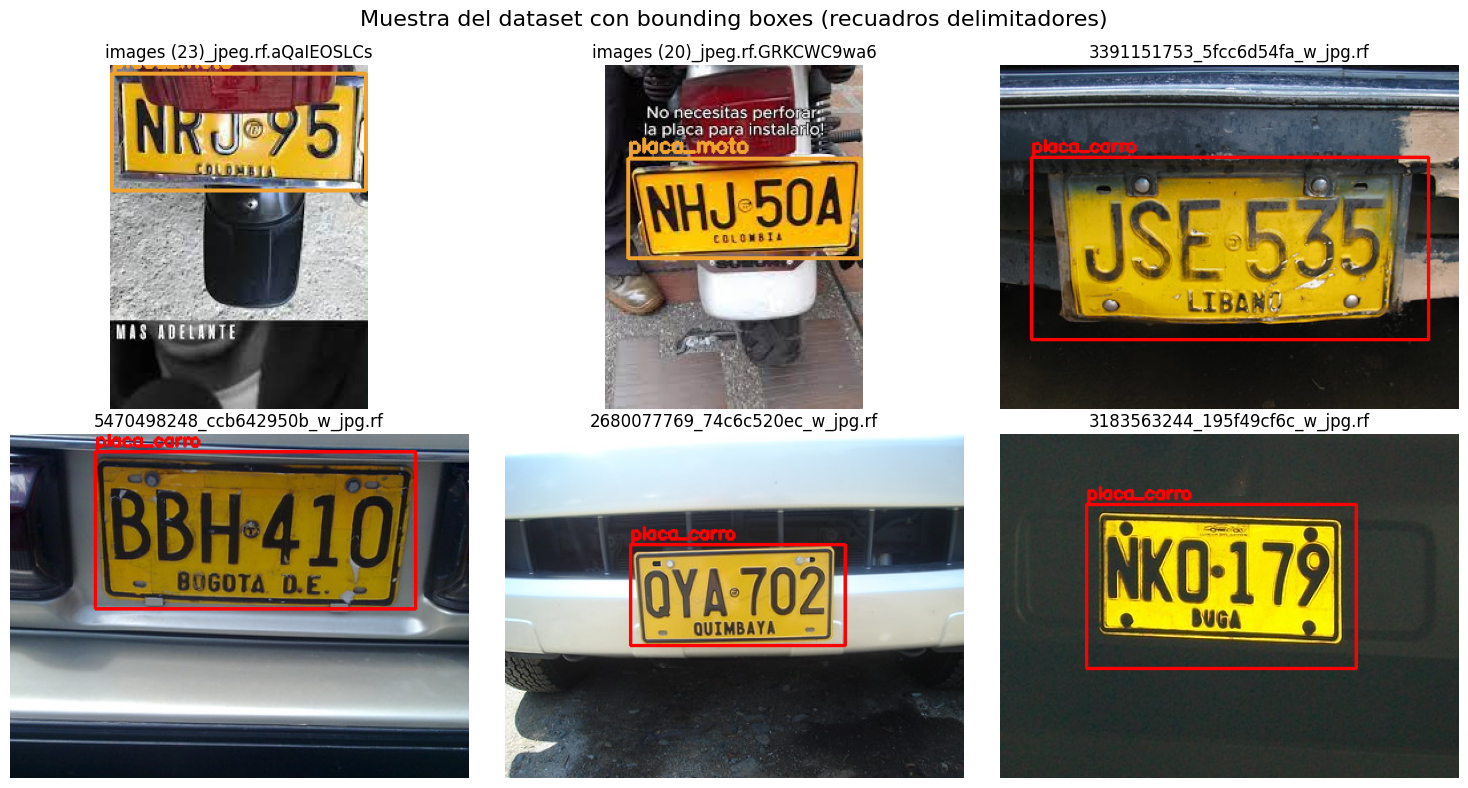

In [93]:
COLORES = {0:(255,0,0), 1:(240,162,46)} # rojo = carro, naranja = moto
NOMBRES = {0: 'placa_carro', 1: 'placa_moto'}

iamgenes_procesadas = list(PROCESSED_IMAGES.glob("*"))
muestra = random.sample(iamgenes_procesadas, 6)

fig, axes = plt.subplots(2,3, figsize=(15,8))
fig.suptitle('Muestra del dataset con bounding boxes (recuadros delimitadores)', fontsize = 16)

for ax, img_path in zip(axes.flatten(), muestra):
    # Leer imagen 
    imagen = cv2.imread(str(img_path))
    imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    alto, ancho = imagen.shape[:2]
    # Leer label correspondiente 
    label_path = PROCESSED_LABELS / (img_path.stem + ".txt")

    if label_path.exists():
        with open(label_path, 'r') as f: 
            for linea in f.readlines():
                datos = linea.strip().split()
                clase = int(datos[0])
                centro_x,centro_y,ancho_caja,alto_caja = float(datos[1]), float(datos[2]), float(datos[3]), float(datos[4])
                #Convertir coordenadas normalizadas a píxeles (coordenadas YOLO a píxeles reales)
                x1 = int((centro_x - ancho_caja/2) * ancho)
                y1 = int((centro_y - alto_caja/2) * alto)
                x2 = int((centro_x + ancho_caja/2) * ancho)
                y2 = int((centro_y + alto_caja/2) * alto)

                # Dibujar bounding box 
                cv2.rectangle(imagen, (x1,y1), (x2,y2), COLORES[clase], 2)
                cv2.putText(imagen, NOMBRES[clase], (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, COLORES[clase],2 )
                
    ax.imshow(imagen)
    ax.axis('off')
    ax.set_title(img_path.name[:30])

plt.tight_layout()
plt.show()


Nota: visualizamos 6 imagenes aletoriamente del dataset con sus bounding boxes dibujados, los recuadros rojos 
corresponden a la placa_carro y los naranjas a placa_moto, podemos observar que las anotaciones aparantemente están bien en su mayoria.

# Redimensionamiento y normalización.

Yolo maneja automáticamente durante el entrenamiento 
- **Redimensionamiento**: aplica *letterboxing* (mantiene la proporción + paddiing) hasata el tamaño esperado, evitando asi la distorsión de la imagen 
- **Normalización**: escala píxels de 0-255 a 0-1 internamente 
Además, durante el entrenamiento se aplicara **data augmentation** (como flips, escalado o cambios de color) para mejorar la generalización del modelo


la siguiente visualización es solo ilustrativa, represtan el tamaño final, pero no el proceso exacto de *letterboxing* que aplica YOLO

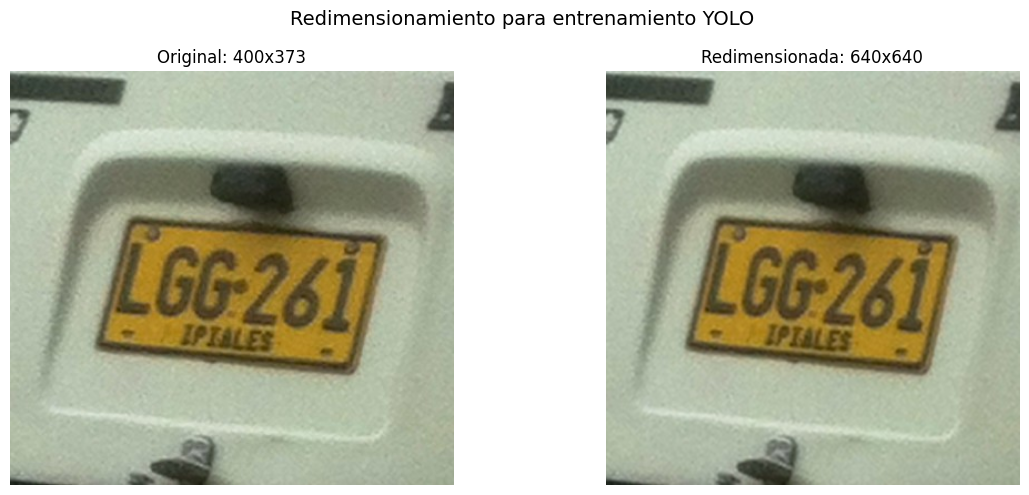

In [ ]:
#ejemplo de redimensionamiento a 640x640
img_ejemplo = cv2.imread(str(imagenes_procesadas[0]))
img_original = cv2.cvtColor(img_ejemplo, cv2.COLOR_BGR2RGB)
# cv2.resize es solo ilustrativo, ya que YOLO aplica letterboxing y no resize directo
img_resized = cv2.resize(img_original, (640, 640))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_original)
axes[0].set_title(f'Original: {img_original.shape[1]}x{img_original.shape[0]}')
axes[0].axis('off')

axes[1].imshow(img_resized)
axes[1].set_title('Redimensionada: 640x640')
axes[1].axis('off')

plt.suptitle('Redimensionamiento para entrenamiento YOLO', fontsize=14)
plt.tight_layout()
plt.show()

## División en conjuntos de entrenamiento, validación y prueba.

In [87]:
SPLITS_PATH = Path("../data/splits")
SPLITS_TRAIN_IMAGES = SPLITS_PATH / "train" / "images"
SPLITS_TRAIN_LABELS = SPLITS_PATH / "train" / "labels"
SPLITS_VALID_IMAGES = SPLITS_PATH / "valid" / "images"
SPLITS_VALID_LABELS = SPLITS_PATH / "valid" / "labels"
SPLITS_TEST_IMAGES  = SPLITS_PATH / "test"  / "images"
SPLITS_TEST_LABELS  = SPLITS_PATH / "test"  / "labels"

# se separa las imágenes por clase para una división balanceada
imagenes_carro = []
imagenes_moto  = []
imagenes_mixtas = []

for img_path in imagenes_procesadas:
    label_path = PROCESSED_LABELS / (img_path.stem + ".txt")
    clases_en_imagen = set()
    
    with open(label_path, 'r') as f:
        for linea in f.readlines():
            datos = linea.strip().split()
            if len(datos) == 5:
                clases_en_imagen.add(int(datos[0]))
    
    if clases_en_imagen == {0}:
        imagenes_carro.append(img_path)
    elif clases_en_imagen == {1}:
        imagenes_moto.append(img_path)
    else:
        imagenes_mixtas.append(img_path)

print(f"Imágenes solo carro:  {len(imagenes_carro)}")
print(f"Imágenes solo moto:   {len(imagenes_moto)}")
print(f"Imágenes mixtas:      {len(imagenes_mixtas)}")

Imágenes solo carro:  244
Imágenes solo moto:   35
Imágenes mixtas:      2


Nota: solo hay dos imagenes que contienen tanto placas de carro como de moto, es distribuirlas bien, para que queden balanceadas

In [90]:

una_placa = []
multiples_placas = []

imagenes_mixtas_set = set(str(p) for p in imagenes_mixtas)

for img_path in imagenes_procesadas:
    # Se saltan las mixtas
    if str(img_path) in imagenes_mixtas_set:
        continue
        
    label_path = PROCESSED_LABELS / (img_path.stem + ".txt")
    
    with open(label_path, 'r') as f:
        lineas = [l.strip() for l in f.readlines() if l.strip()]
    
    if len(lineas) == 1:
        una_placa.append(img_path)
    else:
        multiples_placas.append(img_path)

print(f"Imágenes con una placa:        {len(una_placa)}")
print(f"Imágenes con múltiples placas: {len(multiples_placas)}")
print(f"Imágenes mixtas:               {len(imagenes_mixtas)}")


Imágenes con una placa:        275
Imágenes con múltiples placas: 4
Imágenes mixtas:               2


Nota: identificamos las imágenes con multiples placas excluyendo las mixtas, ya que tambien es importante tenerla presente para una distribución balanceada 

#### División de datasets


In [91]:
random.seed(42)  

def dividir_estratificado(lista, train=0.70, valid=0.20):
    random.shuffle(lista) # Orden aleatorio
    n = len(lista)
    n_train = int(n * train)
    n_valid = int(n * valid)
    return lista[:n_train], lista[n_train:n_train+n_valid], lista[n_train+n_valid:]

# Separar una_placa por clase
una_placa_carro = [p for p in una_placa if p in imagenes_carro]
una_placa_moto  = [p for p in una_placa if p in imagenes_moto]

# Dividir estratificadamente
train_carro, valid_carro, test_carro = dividir_estratificado(una_placa_carro)
train_moto,  valid_moto,  test_moto  = dividir_estratificado(una_placa_moto)

# Múltiples placas — manual
random.shuffle(multiples_placas)
train_multi = multiples_placas[:2]
valid_multi = multiples_placas[2:3]
test_multi  = multiples_placas[3:]

# Mixtas — manual
random.shuffle(imagenes_mixtas)
train_mixtas = [imagenes_mixtas[0]]
valid_mixtas = [imagenes_mixtas[1]]
test_mixtas  = [imagenes_mixtas[0]]  # reutilizamos en test

# Combinar todo
train_final = train_carro + train_moto + train_multi + train_mixtas
valid_final = valid_carro + valid_moto + valid_multi + valid_mixtas
test_final  = test_carro  + test_moto  + test_multi  + test_mixtas

print(f"Train: {len(train_final)} imágenes")
print(f"Valid: {len(valid_final)} imágenes")
print(f"Test:  {len(test_final)} imágenes")
print(f"Total: {len(train_final) + len(valid_final) + len(test_final)}")

Train: 195 imágenes
Valid: 56 imágenes
Test:  31 imágenes
Total: 282


Nota: el dataset se dividio de manera estratificada de modo que cada split contenga de manera proporcional todas las categorias, de este modo garantizamos que el modelo sea evaluado con la misma variedad de condicones con las que fue entrenado 
- *Imágenes con una sola placa (275)*: se dividen 70/20/10 por clase
- *Imágenes con múltiples placas (4)*: distribución manual: 2 en train, 1 valid, 1 test
- *Imágenes mixtas carrro+moto (2)*: distribución manual: 1 train, 1 valid, 1 test(es la misma de train)

#### Asiganción de la repartición 

In [94]:
def copiar_split(lista_imagenes, dest_images, dest_labels):
    for img_path in lista_imagenes:
        # Copiar imagen
        shutil.copy(str(img_path), str(dest_images / img_path.name))
        # Copiar label
        label_path = PROCESSED_LABELS / (img_path.stem + ".txt")
        if label_path.exists():
            shutil.copy(str(label_path), str(dest_labels / (img_path.stem + ".txt")))

# Copiar cada split
copiar_split(train_final, SPLITS_TRAIN_IMAGES, SPLITS_TRAIN_LABELS)
copiar_split(valid_final, SPLITS_VALID_IMAGES, SPLITS_VALID_LABELS)
copiar_split(test_final,  SPLITS_TEST_IMAGES,  SPLITS_TEST_LABELS)

# Verificar
print(f"Train — imágenes: {len(list(SPLITS_TRAIN_IMAGES.glob('*')))} labels: {len(list(SPLITS_TRAIN_LABELS.glob('*.txt')))}")
print(f"Valid — imágenes: {len(list(SPLITS_VALID_IMAGES.glob('*')))} labels: {len(list(SPLITS_VALID_LABELS.glob('*.txt')))}")
print(f"Test  — imágenes: {len(list(SPLITS_TEST_IMAGES.glob('*')))}  labels: {len(list(SPLITS_TEST_LABELS.glob('*.txt')))}")


Train — imágenes: 195 labels: 195
Valid — imágenes: 56 labels: 56
Test  — imágenes: 31  labels: 31


#### Asiganación del yaml

In [97]:

data_yaml = {
    'train': str(SPLITS_TRAIN_IMAGES.resolve()),
    'val':   str(SPLITS_VALID_IMAGES.resolve()),
    'test':  str(SPLITS_TEST_IMAGES.resolve()),
    'nc': 2,
    'names': ['placa_carro', 'placa_moto']
}

yaml_path = Path("../data/splits/data.yaml")
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)

print(f"data.yaml generado en {yaml_path}")


data.yaml generado en ..\data\splits\data.yaml


#### Conclusiones

- Dataset original de 281 imágenes preservado intacto en `data/raw/`
- 137 anotaciones en formato polígono convertidas a bounding box estándar YOLOv8
- Dataset procesado y limpio disponible en `data/processed/`
- División estratificada completada en `data/splits/` — 195 train, 56 valid, 31 test
- `data.yaml` generado con rutas absolutas listas para entrenamiento
- El dataset está listo para entrenar el modelo YOLO